# Import Library

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statistics as st

from sklearn.preprocessing import OneHotEncoder as ohe, PolynomialFeatures as pf, StandardScaler as ss
from sklearn.model_selection import train_test_split as tts
from sklearn.linear_model import LinearRegression as lr, Ridge as  ri, Lasso as la
from sklearn.compose import ColumnTransformer as ct
from sklearn.datasets import fetch_california_housing
from sklearn.metrics import mean_absolute_error as mae, mean_squared_error as mse, r2_score as r2, accuracy_score as ac, precision_score as ps

from sklearn.linear_model import Ridge, RidgeCV, LassoCV, ElasticNet, ElasticNetCV
from sklearn.metrics import r2_score
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor

# Load, EDA, Seprate(x,y), Feature Scaling on Dataset

In [2]:
# Load Dataset
df = fetch_california_housing(as_frame=True)
df = df.frame
# EDA
print(df.info())
print(df.describe())
print(df.isnull().sum())
df.head()

# Separate Data on X and Y Variable
x = df.iloc[:, :-1].values
y = df.iloc[:, -1].values
# Divide data in Training and Testing
x_train, x_test, y_train, y_test = tts(x, y, test_size = 0.2, random_state = 0)

# Scaling Data
Scaler = ss()
x_train = Scaler.fit_transform(x_train)
x_test = Scaler.transform(x_test)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB
None
             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.429000      1.096675   1425.476744   
std        1.899822     12.585558      2.474173      0.473911   1132.462122   
min        0.499900      1.000000      0.846154      0.333333      3.

# 1.Initilize Linear Regression

In [3]:
lr_model = lr()
# Linear Regression Model Learn From Training Data
lr_model.fit(x_train, y_train)
# Pridiction From Linear Regression Model
lr_pred = lr_model.predict(x_test)
print("R2 Score by Linear Regression :\t", r2(y_test, lr_pred));

R2 Score by Linear Regression :	 0.5943232652466204


# Ridge Regression Initilize

In [4]:
ridge_regression = ri(alpha = 0.1)

# Ridge Regression Learn by Training Data
ridge_regression.fit(x_train, y_train)

# Ridge Modle Pridiction on Test Dataset
y_pred_ridge_model = ridge_regression.predict(x_test)    

# Ridge Regression Strenght
print("R2 Score by Ridge Regression :\t", r2(y_test, y_pred_ridge_model))

R2 Score by Ridge Regression :	 0.594322358005935


In [5]:
def find_best_alpha():
    best_r2 = float("-inf")
    best_alpha = None

    for alpha in range(1, 10):
        ridge = ri(alpha=alpha)
        ridge.fit(x_train, y_train)

        y_pred = ridge.predict(x_test)
        r2_val = r2(y_test, y_pred)

        if r2_val > best_r2:
            best_r2 = r2_val
            best_alpha = alpha

    print(f"Best Alpha:\t {best_alpha}")
    print(f"Best R2 Score:\t {best_r2:.4f}")

find_best_alpha()


Best Alpha:	 1
Best R2 Score:	 0.5943


In [6]:
# Define the alphas you want to test
alphas = range(1, 10)

# RidgeCV automatically finds the best alpha using Cross-Validation
# store_cv_values=True allows you to see the scores if needed
clf = RidgeCV(alphas=alphas).fit(x_train, y_train)

print(f"Best alpha: {clf.alpha_}")
print(f"Best R2 score: {clf.score(x_test, y_test):.4f}")

Best alpha: 9
Best R2 score: 0.5942


# Lasso Regression Initilize

In [7]:
#  Simple
lasso_regression = la(alpha = 1.0)

# lasso Regression Learn by Training Data
lasso_regression.fit(x_train, y_train)

# Ridge Modle Pridiction on Test Dataset
y_pred_lasso_model = lasso_regression.predict(x_test)

# Lasso Regression Strength
print("R2 Score by Lasso Regression :\t", r2(y_test, y_pred_lasso_model))

R2 Score by Lasso Regression :	 -0.00029774466534027155


In [8]:
# Find Best Alpha By Function 
def best_alpha_lasso():
    best_r2 = float("-inf")
    best_alpha = None
    for alpha in range(1, 10):
        lasso = la(alpha = alpha/10)
        lasso.fit(x_train, y_train)
        y_pred = lasso.predict(x_test)
        r2_score = r2(y_test, y_pred)
        if r2_score > best_r2:
            best_r2 = r2_score
            best_alpha = alpha
    print(f"Best Alpha : {best_alpha/10} \n Best R2 Score : {best_r2}")

best_alpha_lasso()

Best Alpha : 0.1 
 Best R2 Score : 0.47081317803600764


All Coefficients:
Study_Hours    15.173617
Attendance      1.335653
Shoe_Size       0.000000
Fav_Color      -0.000000
dtype: float64

-----------------------------
FINAL SELECTED FEATURES:
['Study_Hours', 'Attendance']


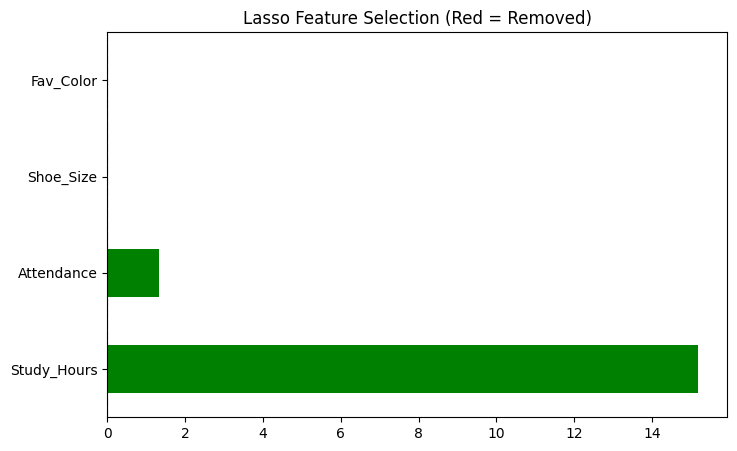

In [9]:
# Feature Selection

import pandas as pd
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# 1. PREPARE SAMPLE DATA (Replace this with your pd.read_csv)
data = {
    'Study_Hours': [2, 3, 8, 10, 1],
    'Attendance': [90, 85, 95, 98, 50],
    'Shoe_Size': [8, 9, 8, 10, 7],     # Irrelevant feature
    'Fav_Color': [1, 2, 1, 3, 2],      # Irrelevant feature
    'Exam_Score': [60, 65, 90, 95, 52] # Target
}
df = pd.DataFrame(data)

# 2. SEPARATE FEATURES & TARGET
# We save the column names here to avoid the AttributeError later
X_original = df.drop('Exam_Score', axis=1) 
y = df['Exam_Score']

# 3. SCALING (Crucial for Lasso)
# Lasso assumes all features are on the same scale (e.g., 0 to 1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_original) # This turns X into a numpy array

# 4. SPLIT DATA
x_train, x_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# 5. FIT LASSO MODEL
# alpha = Strength of penalty. 
# Higher alpha = More features become zero.
lasso = Lasso(alpha=1.0) 
lasso.fit(x_train, y_train)

# 6. EXTRACT FEATURES (The Logic)
# We use X_original.columns because 'x_train' lost its names during scaling
coef_dict = pd.Series(lasso.coef_, index=X_original.columns)

# 7. PRINT RESULTS
print("All Coefficients:")
print(coef_dict)

print("\n-----------------------------")
print("FINAL SELECTED FEATURES:")
# Filter only those that are NOT zero
selected = coef_dict[coef_dict != 0].index.tolist()
print(selected)

# Visulization
import matplotlib.pyplot as plt

# Plotting the coefficients
plt.figure(figsize=(8, 5))
coef_dict.plot(kind='barh', color=np.where(coef_dict == 0, 'red', 'green'))
plt.title('Lasso Feature Selection (Red = Removed)')
plt.axvline(x=0, color='black', linestyle='--')
plt.show()


# ElasticNet Initilize

In [10]:
# 1. Create the model
# l1_ratio = 0.5 (Half Lasso(l1), Half Ridge(l2))
elastic_net = ElasticNet(alpha=1.0, l1_ratio= 0.10)

# 2. Train
elastic_net.fit(x_train, y_train)

# 3. Predict
y_pred = elastic_net.predict(x_test)

# 4. Result 
r2_Score = r2(y_test, y_pred)
print(r2_Score)

nan


C:\Users\puruj\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_regression.py:1283: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)


In [11]:
# Find Best l1_ratio
def Find_Best_l1_ratio():
    best_r2 = float('-inf')
    best_ratio = None
    for ratio in range(1, 100):
        elastic_net = ElasticNet(alpha = 1.0, l1_ratio = ratio/100)
        elastic_net.fit(x_train, y_train)
        y_pred = elastic_net.predict(x_test)
        r2_score = r2(y_test, y_pred)
        if r2_score > best_r2:
            best_r2 = r2_score
            best_ratio = ratio
    print(f"Best Ratio : \t {best_ratio}")
    print(f"Best R2 Score : \t {best_r2}")


Find_Best_l1_ratio()

Best Ratio : 	 None
Best R2 Score : 	 -inf


C:\Users\puruj\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_regression.py:1283: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
C:\Users\puruj\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_regression.py:1283: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
C:\Users\puruj\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_regression.py:1283: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
C:\Users\puruj\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_regression.py:1283: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
C:\Users\puruj\AppData\Local\Programs\Python\Python3

In [12]:
# By Elastic CV Find Best Alpha and Ratio
ratio = np.linspace(0.01, 0.99, 99)

model = ElasticNetCV(l1_ratio=ratio, cv=5, random_state=42)
model.fit(x_train, y_train)
print(f"Best alpha found: {model.alpha_}")
print(f"Best l1_ratio found: {model.l1_ratio_}")


ValueError: Cannot have number of splits n_splits=5 greater than the number of samples: n_samples=4.

In [13]:
from sklearn.model_selection import GridSearchCV

# 1. Define the dictionary of things to test
param_grid = {
    'alpha': [0.001, 0.01, 0.1, 1, 10, 100],
    'l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9, 0.99]
}

# 2. Create the Grid Search object
grid_search = GridSearchCV(
    estimator=ElasticNet(),
    param_grid=param_grid,
    scoring='r2',
    cv=5,      # Cross Validation splits
    verbose=1  # Prints progress
)

# 3. Fit (This runs the nested loops automatically)
grid_search.fit(x_train, y_train)

# 4. Get the winner
print("Best Params:", grid_search.best_params_)
print("Best Score:", grid_search.best_score_)

Fitting 5 folds for each of 36 candidates, totalling 180 fits


ValueError: Cannot have number of splits n_splits=5 greater than the number of samples: n_samples=4.

# Same By PipleLine

In [14]:
pipe = Pipeline([
    ('scaler', ss()),
    ('model', ElasticNet(alpha = 0.0023055809080480363, l1_ratio = 0.99))]).fit(x_train, y_train)
y_pred = pipe.predict(x_test)
r2_Score = r2(y_test, y_pred)
r2_Score

C:\Users\puruj\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_regression.py:1283: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)


nan

In [15]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score

# Import the regression models you want to test
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor

def find_best_regression_model(X, y, test_size=0.2, random_state=42):
    """
    Iterates through multiple regression models, performs hyperparameter tuning
    using GridSearchCV, and returns the best model based on R2 score.
    
    Args:
        X: Features (DataFrame or array)
        y: Target variable (Series or array)
        
    Returns:
        DataFrame of results and the best model object.
    """
    
    # 1. Split the data
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=random_state)
    
    # 2. Define a dictionary of models and their specific hyperparameter grids
    # Note: We use 'model__' prefix because the model is step 2 in the pipeline
    models_config = {
        'Linear Regression': {
            'model': LinearRegression(),
            'params': {} # Linear Regression usually doesn't need hyperparams
        },
        'Ridge': {
            'model': Ridge(),
            'params': {
                'model__alpha': [0.01, 0.1, 1, 10, 100]
            }
        },
        'Lasso': {
            'model': Lasso(),
            'params': {
                'model__alpha': [0.001, 0.01, 0.1, 1, 10]
            }
        },
        'ElasticNet': {
            'model': ElasticNet(),
            'params': {
                'model__alpha': [0.001, 0.01, 0.1, 1, 10],
                'model__l1_ratio': [0.1, 0.5, 0.7, 0.9, 0.99]
            }
        },
        'Random Forest': {
            'model': RandomForestRegressor(random_state=random_state),
            'params': {
                'model__n_estimators': [50, 100],
                'model__max_depth': [None, 10, 20]
            }
        }
    }
    
    results = []
    best_overall_model = None
    best_overall_score = -np.inf
    
    print(f"Training models on {X_train.shape[0]} samples...")
    print("-" * 50)

    # 3. Loop through every model in the config
    for name, config in models_config.items():
        # Create a pipeline for each model
        # Scaling is crucial for Linear/Ridge/Lasso/ElasticNet
        pipe = Pipeline([
            ('scaler', StandardScaler()),
            ('model', config['model'])
        ])
        
        # Run Grid Search to find best params for this specific model
        grid = GridSearchCV(pipe, config['params'], cv=5, scoring='r2', n_jobs=-1)
        grid.fit(X_train, y_train)
        
        # 4. Evaluate on Test Set
        # grid.best_estimator_ is the pipeline with the best found parameters
        y_pred = grid.best_estimator_.predict(X_test)
        test_r2 = r2_score(y_test, y_pred)
        
        # Store results
        results.append({
            'Model': name,
            'Test_R2_Score': test_r2,
            'Best_CV_Score': grid.best_score_, # Mean cross-validation score
            'Best_Params': grid.best_params_
        })
        
        # Track the absolute best model
        if test_r2 > best_overall_score:
            best_overall_score = test_r2
            best_overall_model = grid.best_estimator_
            
    # 5. Create a clean DataFrame for comparison
    results_df = pd.DataFrame(results).sort_values(by='Test_R2_Score', ascending=False)
    
    print("\nModel Evaluation Results:")
    print(results_df[['Model', 'Test_R2_Score', 'Best_Params']])
    
    return results_df, best_overall_model

# --- EXAMPLE USAGE ---

# Run the function
df_results, final_model = find_best_regression_model(x, y)

print("\n-----------------------------------")
print(f"The Winner is: {df_results.iloc[0]['Model']}")
print(f"With R2 Score: {df_results.iloc[0]['Test_R2_Score']:.4f}")
print("Parameters:", df_results.iloc[0]['Best_Params'])

ValueError: Found input variables with inconsistent numbers of samples: [20640, 5]

In [16]:
# Find Best Random Forest
def Find_Best_RF_Params_Advanced():
    best_r2 = float('-inf')
    best_n = None
    best_depth = None
    
    # Loop for n_estimators (Trees)
    for n in [50, 100, 150, 200]:
        # Loop for max_depth (Depth of each tree)
        for d in [None, 10, 20, 30]:
            
            rf = RandomForestRegressor(n_estimators = n, max_depth = d, random_state=42)
            rf.fit(x_train, y_train)
            y_pred = rf.predict(x_test)
            score = r2_score(y_test, y_pred)
            
            if score > best_r2:
                best_r2 = score
                best_n = n
                best_depth = d
                
    print(f"Best n_estimators : \t {best_n}")
    print(f"Best max_depth : \t {best_depth}")
    print(f"Best R2 Score : \t {best_r2}")

Find_Best_RF_Params_Advanced()

C:\Users\puruj\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_regression.py:1283: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
C:\Users\puruj\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_regression.py:1283: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
C:\Users\puruj\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_regression.py:1283: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
C:\Users\puruj\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_regression.py:1283: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
C:\Users\puruj\AppData\Local\Programs\Python\Python3

Best n_estimators : 	 None
Best max_depth : 	 None
Best R2 Score : 	 -inf


C:\Users\puruj\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_regression.py:1283: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)


In [17]:
rf = RandomForestRegressor(n_estimators = 200, max_depth = None, random_state=42)
rf.fit(x_train, y_train)
y_pred = rf.predict(x_test)
score = r2_score(y_test, y_pred)
score

C:\Users\puruj\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_regression.py:1283: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)


nan